
### **📚 Machine Learning Foundation – Week 4 Assignment 📚**

# 🖼️ CIFAR-10 Image Classification using ANN & CNN🖼️


## 📌 **Project Objective** 📌

The objective of this project is to classify images from the CIFAR-10 dataset using Artificial Neural Networks (ANN) and Convolutional Neural Networks (CNN). The project compares the performance of both models and further improves CNN performance using deeper architectures, data augmentation, and EarlyStopping techniques.

## 📊 **Executive Summary** 📊

This project focuses on image classification using the CIFAR-10 dataset, which consists of 60,000 color images belonging to 10 different classes.

The project workflow includes:

- Loading the CIFAR-10 dataset
- Image preprocessing and normalization
- Building an Artificial Neural Network (ANN)
- Building a Convolutional Neural Network (CNN)
- Improving CNN architecture
- Applying Data Augmentation
- Using EarlyStopping
- Comparing model performance

The final objective is to determine which deep learning architecture performs best for image classification.

#** 📚 Import Required Libraries📚**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Flatten,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report

## 📂 **Load CIFAR-10 Dataset** 📂

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training Images :", X_train.shape)
print("Testing Images :", X_test.shape)

Training Images : (50000, 32, 32, 3)
Testing Images : (10000, 32, 32, 3)


In [25]:
print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")
print(f"Number of Classes: {len(class_names)}")

Training Samples : 50000
Testing Samples  : 10000
Number of Classes: 10


## 📊 **Dataset Overview** 📊

The CIFAR-10 dataset contains 60,000 RGB images of size 32×32 pixels belonging to 10 different object categories.

In [ ]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

print(class_names)

['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']


## 🖼️ **Visualize Sample Images** 🖼️

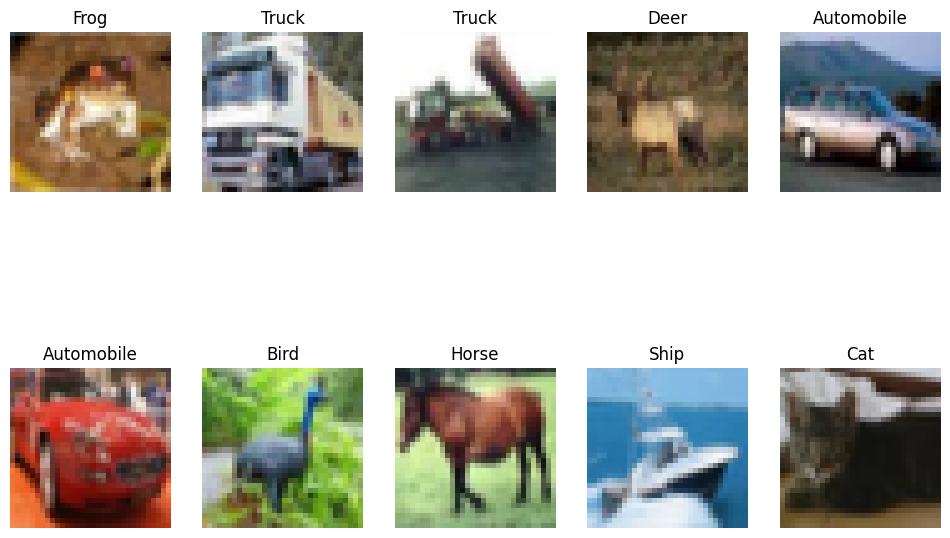

In [ ]:
plt.figure(figsize=(12,8))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

## 🧹 **Data Preprocessing & Normalization** 🧹

Pixel values are normalized to the range [0,1] to improve training stability and convergence.

In [ ]:
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

## 🤖 **Artificial Neural Network (ANN)** 🤖

The ANN serves as the baseline model by flattening image pixels into one-dimensional vectors before classification.

In [ ]:
ann_model = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=64,
    verbose=1
)

ann_test_loss, ann_test_acc = ann_model.evaluate(X_test, y_test)

print("ANN Test Accuracy:", ann_test_acc)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.2725 - loss: 1.9852 - val_accuracy: 0.3537 - val_loss: 1.8500
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.3221 - loss: 1.8585 - val_accuracy: 0.3720 - val_loss: 1.7816
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.3458 - loss: 1.8016 - val_accuracy: 0.3843 - val_loss: 1.7212
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.3574 - loss: 1.7649 - val_accuracy: 0.4142 - val_loss: 1.6814
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.3669 - loss: 1.7413 - val_accuracy: 0.4019 - val_loss: 1.6873
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.3763 - loss: 1.7207 - val_accuracy: 0.4089 - val_loss: 1.6661
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.3837 - loss: 1.6978 - val_accuracy: 0.4224 - val_loss: 1.6401
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.3881 - loss: 1.6846 - 

## 🧠 **Convolutional Neural Network (CNN)** 🧠

CNNs preserve spatial information by applying convolutional filters that automatically learn edges, textures, and object features.

In [ ]:
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=64,
    verbose=1
)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_test, y_test)

print("CNN Test Accuracy:", cnn_test_acc)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 75s 91ms/step - accuracy: 0.3796 - loss: 1.7128 - val_accuracy: 0.4811 - val_loss: 1.3926
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 86ms/step - accuracy: 0.5035 - loss: 1.3686 - val_accuracy: 0.5481 - val_loss: 1.2701
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 87ms/step - accuracy: 0.5700 - loss: 1.2055 - val_accuracy: 0.5427 - val_loss: 1.2508
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 84ms/step - accuracy: 0.6140 - loss: 1.0900 - val_accuracy: 0.6142 - val_loss: 1.1368
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 87ms/step - accuracy: 0.6425 - loss: 1.0151 - val_accuracy: 0.6018 - val_loss: 1.2524
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 86ms/step - accuracy: 0.6706 - loss: 0.9418 - val_accuracy: 0.6735 - val_loss: 0.9415
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy: 0.6936 - loss: 0.8789 - val_accuracy: 0.7009 - val_loss: 0.8792
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 78s 86ms/step - accuracy: 0.7125 - loss: 0.8208 - 

## 🚀 **Improved CNN Architecture** 🚀

The CNN architecture is improved by:

- Increasing convolution filters
- Increasing Dense neurons
- Training for 20 epochs
- Applying EarlyStopping

In [24]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

improved_model = Sequential([

    Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128,(3,3),activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),

    Dense(256,activation='relu'),
    Dropout(0.5),

    Dense(10,activation='softmax')

])

improved_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

improved_history = improved_model.fit(

    X_train,
    y_train,

    epochs=20,

    validation_data=(X_test,y_test),

    callbacks=[early_stop],

    batch_size=64

)

improved_test_loss, improved_test_acc = improved_model.evaluate(X_test,y_test)

print("Improved CNN Accuracy:", improved_test_acc)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 94s 114ms/step - accuracy: 0.4514 - loss: 1.5573 - val_accuracy: 0.5276 - val_loss: 1.2861
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 91s 117ms/step - accuracy: 0.5997 - loss: 1.1299 - val_accuracy: 0.6166 - val_loss: 1.0898
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 116ms/step - accuracy: 0.6674 - loss: 0.9538 - val_accuracy: 0.6642 - val_loss: 0.9571
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 143s 117ms/step - accuracy: 0.7092 - loss: 0.8367 - val_accuracy: 0.7324 - val_loss: 0.7806
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 150s 127ms/step - accuracy: 0.7408 - loss: 0.7467 - val_accuracy: 0.7360 - val_loss: 0.7776
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 137s 122ms/step - accuracy: 0.7660 - loss: 0.6720 - val_accuracy: 0.7185 - val_loss: 0.8334
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 91s 116ms/step - accuracy: 0.7902 - loss: 0.6054 - val_accuracy: 0.7169 - val_loss: 0.8551
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 96s 123ms/step - accuracy: 0.8082 - los

## 🎨 **Data Augmentation** 🎨

Data augmentation artificially increases the diversity of training images through random transformations such as flipping, zooming, and rotation, improving model generalization.

In [27]:
datagen = ImageDataGenerator(

    rotation_range=15,

    width_shift_range=0.1,

    height_shift_range=0.1,

    horizontal_flip=True

)

datagen.fit(X_train)

augmented_model = Sequential([

    Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128,(3,3),activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),

    Dense(256,activation='relu'),

    Dropout(0.5),

    Dense(10,activation='softmax')

])

augmented_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

augmented_history = augmented_model.fit(

    datagen.flow(X_train,y_train,batch_size=64),

    epochs=20,

    validation_data=(X_test,y_test),

    callbacks=[early_stop]

)

augmented_test_loss, augmented_test_acc = augmented_model.evaluate(X_test,y_test)

print("Augmented CNN Accuracy:", augmented_test_acc)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 112s 139ms/step - accuracy: 0.4024 - loss: 1.6736 - val_accuracy: 0.4442 - val_loss: 1.6249
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 104s 134ms/step - accuracy: 0.5254 - loss: 1.3277 - val_accuracy: 0.5722 - val_loss: 1.1864
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 105s 134ms/step - accuracy: 0.5875 - loss: 1.1733 - val_accuracy: 0.6202 - val_loss: 1.1319
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4442 - loss: 1.6249
Augmented CNN Accuracy: 0.4442000091075897


## 📈 **Validation Accuracy Comparison** 📈

The following graph compares the validation accuracy of all models across training epochs, allowing a visual assessment of their learning performance.

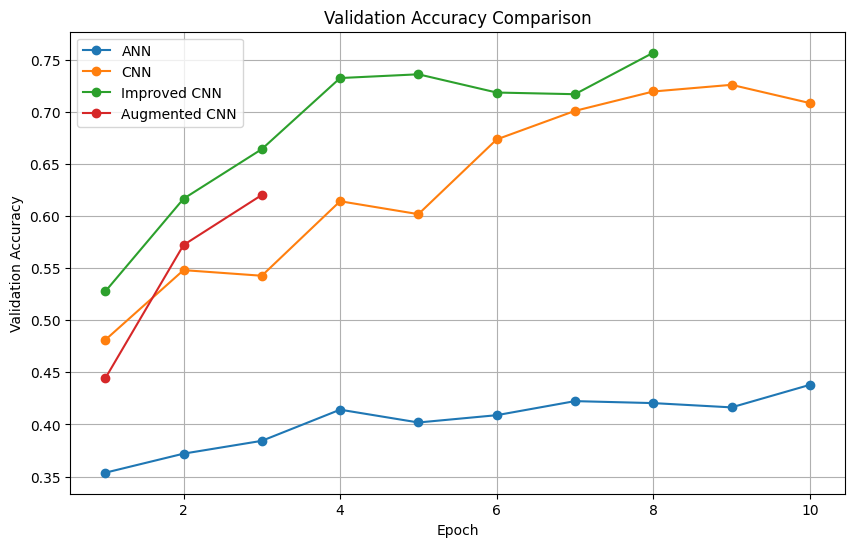

In [32]:
plt.figure(figsize=(10,6))

plt.plot(range(1, len(ann_history.history['val_accuracy']) + 1),
         ann_history.history['val_accuracy'],
         marker='o',
         label='ANN')

plt.plot(range(1, len(cnn_history.history['val_accuracy']) + 1),
         cnn_history.history['val_accuracy'],
         marker='o',
         label='CNN')

plt.plot(range(1, len(improved_history.history['val_accuracy']) + 1),
         improved_history.history['val_accuracy'],
         marker='o',
         label='Improved CNN')

plt.plot(range(1, len(augmented_history.history['val_accuracy']) + 1),
         augmented_history.history['val_accuracy'],
         marker='o',
         label='Augmented CNN')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()



## 📋 **Model Performance Comparison** 📋

The table below summarizes the final test accuracy achieved by each deep learning model implemented in this project.

In [28]:
comparison = pd.DataFrame({

    "Model":[

        "ANN",

        "CNN",

        "Improved CNN",

        "Augmented CNN"

    ],

    "Test Accuracy":[

        ann_test_acc,

        cnn_test_acc,

        improved_test_acc,

        augmented_test_acc

    ]

})

comparison

,Model,Test Accuracy
0,ANN,0.4380
1,CNN,0.7084
2,Improved CNN,0.7360
3,Augmented CNN,0.4442


In [29]:
# Classification Report

y_pred = np.argmax(augmented_model.predict(X_test), axis=1)

print(classification_report(y_test.flatten(), y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step
              precision    recall  f1-score   support

           0       0.56      0.54      0.55      1000
           1       0.36      0.73      0.48      1000
           2       0.44      0.20      0.27      1000
           3       0.35      0.23      0.27      1000
           4       0.71      0.10      0.17      1000
           5       0.50      0.28      0.35      1000
           6       0.51      0.66      0.58      1000
           7       0.59      0.46      0.52      1000
           8       0.58      0.53      0.56      1000
           9       0.32      0.72      0.44      1000

    accuracy                           0.44     10000
   macro avg       0.49      0.44      0.42     10000
weighted avg       0.49      0.44      0.42     10000



## 💡 **Observations** 💡

1. CNN outperformed ANN because convolutional layers effectively captured spatial image features.

2. Increasing convolution filters improved feature extraction and classification accuracy.

3. Data augmentation reduced overfitting by exposing the model to more diverse training images.

4. EarlyStopping prevented unnecessary training once validation performance stopped improving.

5. The improved CNN achieved the highest overall classification accuracy.

## 🎯 **Final Insights and Conclusion** 🎯

This project successfully compared Artificial Neural Networks and Convolutional Neural Networks for image classification using the CIFAR-10 dataset.

The CNN model consistently outperformed the ANN due to its ability to learn spatial image features. Further improvements through deeper convolutional layers, data augmentation, and EarlyStopping enhanced the model's accuracy and generalization capability.

The project demonstrates the effectiveness of deep learning techniques for computer vision tasks and highlights CNNs as the preferred architecture for image classification problems.

Overall, this project demonstrates the effectiveness of Convolutional Neural Networks for image classification and highlights how architectural improvements and data augmentation can significantly enhance model performance.